# Runbook: fracdiff features against returns in a purged-CV classifier, net of costs (SYNTHETIC data)

> **Every number in this notebook is computed on SYNTHETIC data.** The main study uses price paths
> simulated below with a **planted, documented signal** whose strength is known, and a zero-signal
> version of the same generator as the null control. A second control uses the committed sample
> read by `openquant.data.fetch` (`SYN_A` to `SYN_E`, seeded log-normal random walks, see
> `DATA_SOURCES.md`), on which no feature can predict returns. Nothing here describes a real market.

Runbook 09 (#49) ran AFML Chapter 5's $d$-sweep and decided *not* to promote "the smallest $d$
passing ADF" as a default transform, but it could not answer the second half of #49: **do
fractionally differentiated (FFD) features beat plain returns as classifier inputs, in purged
cross-validation and net of costs?** On random walks no feature predicts anything, so that
question needs data where memory carries a signal. This runbook (#209) plants one: the price is a
random walk plus a slowly mean-reverting mispricing, so the *level* of the price relative to its
past says where the next five bars are likely to go, and a transform that keeps memory has
something to find that the last few returns mostly do not. How much there is to find is bounded by
an oracle that sees the hidden mispricing.

The pipeline follows AFML: FFD (Snippet 5.3) with $d$ chosen on the training folds only, as
runbook 09 recommends; fixed-horizon labels; purged k-fold with an embargo (Snippet 7.3); a
`TrialRegistry` and the deflated Sharpe ratio (Chapter 14; Bailey and López de Prado, 2014).

**Run it on your own data.** The control study reads four environment variables, so it runs
unchanged on any daily OHLCV file `openquant.data` can load. Write the executed copy and figures
outside the repository:

```bash
OPENQUANT_RUNBOOK_SOURCE=/path/to/daily_ohlcv.parquet \
OPENQUANT_RUNBOOK_SYMBOLS=ES,NQ,CL \
OPENQUANT_RUNBOOK_RANGE=2010-01-01:2024-12-31 \
OPENQUANT_RUNBOOK_REGISTRY=$HOME/.openquant/trials-fracdiff-classifier.json \
OPENQUANT_FIGURE_DIR=/tmp/fracdiff-classifier-figures \
  uv run --python .venv/bin/python python notebooks/python/scripts/execute_notebook_cells.py \
    notebooks/python/14_fracdiff_features_classifier.ipynb --out /tmp/14_on_my_data.ipynb
```

`OPENQUANT_RUNBOOK_REGISTRY` keeps the control's trial registry between runs, so every
configuration you try on your data counts toward its deflated Sharpe ratio. For a vendor API,
set `SOURCE` in the parameters cell to a `CallableSource`. The planted-signal study does not
depend on the data source.

## Setup

In [1]:
from __future__ import annotations

import math
import os
import sys
import tempfile
from pathlib import Path

import nbfigures
import numpy as np
import openquant
import polars as pl
from openquant import evaluation, fracdiff
from openquant.cross_validation import (
    count_train_test_overlaps,
    naive_kfold_splits,
    purged_kfold_splits,
)

# ---- planted-signal generator (see Data) --------------------------------------------------------
SEED = 209
N_BARS = 2000  # daily bars per simulated path, about 8 years
SIGMA = 0.01  # daily volatility of the random-walk (efficient price) component
PHI = 0.97  # AR(1) persistence of the hidden mispricing: half-life about 23 bars
S_M = 0.008  # headline shock s.d. of the mispricing (calibrated on the oracle only, see Data)
STRENGTHS = (0.0, 0.004, 0.008)  # Monte Carlo sweep of S_M; 0.0 is the zero-signal control
N_REPS = int(os.environ.get("OPENQUANT_RUNBOOK_REPS", "30"))  # paths per strength

# ---- pipeline (fixed before the first run) --------------------------------------------------------
HORIZON = 5  # label: sign of the log return from the close of t to the close of t + 5
WARMUP = 100  # first event bar: every feature is defined from here (widest FFD window is 73 bars)
FFD_THRESH = 1e-3  # FFD weight floor (Snippet 5.3), as in runbook 09; weight sums are reported
D_GRID = [round(0.1 * i, 1) for i in range(11)]  # d searched on the training folds: 0.0, ..., 1.0
D_FIXED = (0.2, 0.4, 0.6, 0.8)  # fixed-d FFD trials
N_LAGS = 5  # a series' feature vector: its value at t, t-1, ..., t-4
DIFF_HORIZONS = (1, 5, 20, 60)  # integer differences of the log price over these many bars
N_SPLITS, PCT_EMBARGO = 5, 0.01  # purged k-fold (Snippet 7.3)
L2 = 1.0  # ridge penalty of the logistic classifier, on standardised features
COST_BPS = 5.0  # cost per unit of one-way turnover, in basis points
ANN = 252  # annualisation factor: the bars are (simulated) business days
HEADLINE = "ffd_dstar"  # FFD with d chosen on each training fold by the ADF rule of runbook 09
BASELINE = "returns"  # the plain-returns classifier H1 and H2 compare against

# ---- control data source ------------------------------------------------------------------------
# Default: the committed SYNTHETIC sample (no network). Override with the env vars below, or set
# SOURCE to any openquant.data DataSource (e.g. a CallableSource around your vendor's API).
_src_env = os.environ.get("OPENQUANT_RUNBOOK_SOURCE", "").strip()
SOURCE = openquant.data.LocalFileSource(_src_env, name="user-file") if _src_env else None
SYMBOLS = os.environ.get("OPENQUANT_RUNBOOK_SYMBOLS", "SYN_A,SYN_B,SYN_C,SYN_D,SYN_E").split(",")
START, END = os.environ.get("OPENQUANT_RUNBOOK_RANGE", "2022-01-03:2023-12-29").split(":")
SYNTHETIC = SOURCE is None
LABEL = "SYNTHETIC" if SYNTHETIC else "user data"
_reg_env = os.environ.get("OPENQUANT_RUNBOOK_REGISTRY", "").strip()
REGISTRY_DIR = Path(tempfile.mkdtemp(prefix="oq-nb14-"))

print(f"planted signal: phi={PHI}, s_m={S_M}, sigma={SIGMA}, {N_BARS} bars, seed {SEED}")
print(f"Monte Carlo: s_m in {STRENGTHS} x {N_REPS} paths")
print(
    f"control source: {'committed SYNTHETIC sample' if SYNTHETIC else 'user file'}; symbols {SYMBOLS}"
)

planted signal: phi=0.97, s_m=0.008, sigma=0.01, 2000 bars, seed 209
Monte Carlo: s_m in (0.0, 0.004, 0.008) x 30 paths
control source: committed SYNTHETIC sample; symbols ['SYN_A', 'SYN_B', 'SYN_C', 'SYN_D', 'SYN_E']


## Hypothesis

Pre-registered before the first full run of any feature set (the generator was calibrated on
the oracle alone, see Data). "FFD" is the headline feature set `ffd_dstar`: the FFD log price
at $t, \dots, t-4$, with $d$ chosen on each training fold as the smallest $d$ on the grid whose
FFD series rejects a unit root (runbook 09's rule, applied to training data only). "Returns" is
the last five log returns ($d = 1$). "Integer differences" is the log price differenced over 1, 5,
20 and 60 bars. Each is the input of the same L2-penalised logistic classifier, with out-of-fold
probabilities from purged 5-fold CV. Each test is a paired one-sided $t$-test at 5%
($t > 1.645$) over the 30 simulated paths at the headline strength $s_m = 0.008$.

- **H1 (prediction).** FFD's out-of-fold AUC is higher than returns'.
- **H2 (net of costs).** FFD's annualised Sharpe ratio net of 5 bps per unit turnover is higher
  than returns'.
- **H3 (against integer differences).** FFD's out-of-fold AUC is higher than the integer
  differences'.
- **H4 (evidence on one path).** On the headline path, FFD's deflated Sharpe ratio, deflated by
  every configuration recorded in the trial registry, is at least 0.95.

**Controls, where the right answer is "no".** On the zero-signal generator ($s_m = 0$) the H1-H3
differences must *not* be significant (two-sided $|t| < 1.96$). On the `SYN_*` sample, no
configuration may reach a deflated Sharpe ratio of 0.95.

**Decision rule, also fixed in advance.** Promote FFD($d^*_{\text{train}}$) as the default
classifier input over returns only if H1 and H2 are supported and both controls pass; call it
the default over integer differences as well only if H3 is supported too. H4 is reported; a
single path rarely carries enough evidence to pass it.

**What is known in advance.** The expected five-bar return is $(\phi^5 - 1)\,m_t$, a linear
function of the hidden mispricing $m_t$. A logistic classifier on $m_t$ itself (the *oracle*,
not tradable) bounds what any feature set can reach. Reported but not tested: accuracy, gross
Sharpe ratio, turnover, the $d$ chosen per fold, and every fixed-$d$ FFD set.

## Data

### Planted-signal generator

The log price is a random walk plus a hidden AR(1) mispricing,

$$\log P_t = \log 100 + \sum_{s \le t} \sigma\,\varepsilon_s + m_t, \qquad
m_t = \phi\, m_{t-1} + s_m\, \eta_t, \qquad \varepsilon, \eta \sim N(0, 1),$$

with $\sigma = 1\%$ a day, $\phi = 0.97$ (a mispricing halves in about 23 bars) and $s_m = 0.008$,
so $m_t$ has a standard deviation of $s_m/\sqrt{1-\phi^2} \approx 3.3\%$ of the price. The
five-bar return is $\sum \sigma\varepsilon + (m_{t+5} - m_t)$, whose predictable part
$(\phi^5-1)\,m_t$ has a standard deviation of about 0.46% against about 2.4% of noise: a weak
signal, and one only the price's history, not its last move, reveals.

**Calibration disclosure.** $\phi$ and $s_m$ were set with prototype runs of the *oracle* only (a
logistic classifier on $m_t$ in this notebook's purged CV, 20 paths per setting): $\phi = 0.98$
with $s_m \in \{0.002, 0.003, 0.004, 0.006, 0.008, 0.012\}$, $\phi = 0.95$ with
$s_m \in \{0.006, 0.008, 0.012\}$, and $\phi = 0.97$ with $s_m \in \{0.004, 0.006, 0.008\}$. The
headline was chosen where the oracle's net Sharpe ratio is about 0.9 annualised, so the question
is answerable without being easy. No candidate feature set was run before this section and the
hypotheses were written. The Monte Carlo keeps the weaker $s_m = 0.004$ and the null in the sweep.

In [2]:
def simulate(seed, s_m: float, n: int = N_BARS) -> tuple[np.ndarray, np.ndarray]:
    """Log close and hidden mispricing of one planted-signal path."""
    rng = np.random.default_rng(seed)
    walk = np.cumsum(SIGMA * rng.standard_normal(n))
    eta = s_m * rng.standard_normal(n)
    m = np.zeros(n)
    for t in range(1, n):
        m[t] = PHI * m[t - 1] + eta[t]
    return math.log(100.0) + walk + m, m


logp_h, m_h = simulate([SEED, 0], S_M)
planted_hash = openquant.data.dataset_hash(pl.DataFrame({"log_close": logp_h, "m": m_h}))
print(f"headline path: {N_BARS} bars (SYNTHETIC), s.d. of the mispricing {m_h.std():.4f}")
print(f"events: bars {WARMUP} to {N_BARS - HORIZON - 1}, {N_BARS - HORIZON - WARMUP} in all")
# Float bits of the simulated path can differ in the last place between platforms (libm), so the
# hash goes to stderr, which the staleness check ignores; every number derived from it is checked.
print("planted path dataset_hash:", planted_hash, file=sys.stderr)

headline path: 2000 bars (SYNTHETIC), s.d. of the mispricing 0.0288
events: bars 100 to 1994, 1895 in all


planted path dataset_hash: sha256:4b86ce57f0dcb10a36a410a11e030dcea4f634aeaf66865ad592725a304b180d


### Control: the SYNTHETIC `fetch` sample

In [3]:
bars, meta = openquant.data.fetch(SYMBOLS, START, END, source=SOURCE, return_meta=True)
print("source:", meta["source"], f"| {LABEL}" + (", not market data" if SYNTHETIC else ""))
print("rows:", meta["rows"], "| dataset_hash:", meta["dataset_hash"])

control = {
    sym: np.log(bars.filter(pl.col("symbol") == sym).sort("ts")["close"].to_numpy().astype(float))
    for sym in SYMBOLS
}
pl.DataFrame(
    {
        "symbol": SYMBOLS,
        "bars": [len(control[s]) for s in SYMBOLS],
        "events": [len(control[s]) - HORIZON - WARMUP for s in SYMBOLS],
    }
)

source: openquant-synthetic-sample | SYNTHETIC, not market data
rows: 2600 | dataset_hash: sha256:b311c219efb2a19db449767cc8600139c030aad15496b011fc650b4880550eea


symbol,bars,events
str,i64,i64
"""SYN_A""",520,415
"""SYN_B""",520,415
"""SYN_C""",520,415
"""SYN_D""",520,415
"""SYN_E""",520,415


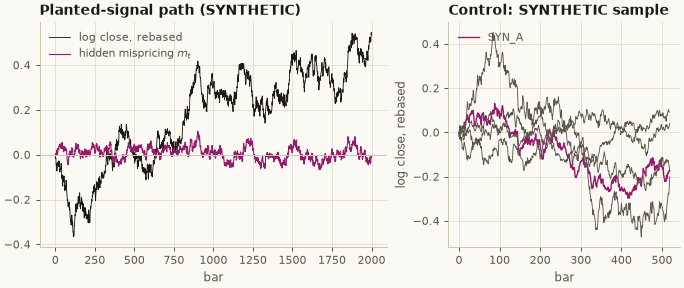

In [4]:
def draw(fig, c):
    left, right = fig.subplots(1, 2, width_ratios=[3, 2])
    x = np.arange(N_BARS)
    left.plot(x, logp_h - logp_h[0], color=c["text"], linewidth=0.7, label="log close, rebased")
    left.plot(x, m_h, color=c["accent"], linewidth=0.9, label="hidden mispricing $m_t$")
    left.axhline(0.0, color=c["rule"], linewidth=0.8)
    left.set_title("Planted-signal path (SYNTHETIC)")
    left.set_xlabel("bar")
    left.legend(loc="upper left")
    for i, sym in enumerate(SYMBOLS):
        lc = control[sym]
        right.plot(
            lc - lc[0],
            color=c["accent"] if i == 0 else c["muted"],
            linewidth=1.1 if i == 0 else 0.7,
            label=sym if i == 0 else None,
        )
    right.set_title(f"Control: {LABEL} sample")
    right.set_ylabel("log close, rebased")
    right.set_xlabel("bar")
    right.legend(loc="upper left")


nbfigures.figure(
    "nb14-inputs",
    draw,
    size=(7.6, 3.2),
    alt="Left: rebased log close of the simulated planted-signal path over 2,000 bars with its hidden mean-reverting mispricing. Right: rebased log closes of the five synthetic sample symbols used as the no-signal control.",
)

## Method

Per series (all indices are bars; bar $t$'s close is known at the end of bar $t$):

1. **Events and labels.** One event per bar $t$ from bar 100 to the last bar with five bars after
   it. Fixed-horizon label (AFML §3.2): $y_t = 1$ if $\log P_{t+5} - \log P_t > 0$, else 0. The
   label spans $[t, t+5]$, so neighbouring labels overlap and purging matters.
2. **Feature sets**, each from closes up to $t$ only:
   - `returns`: the log returns at $t, \dots, t-4$ ($d = 1$);
   - `int_diff`: $\log P_t - \log P_{t-k}$ for $k = 1, 5, 20, 60$ (integer differences at four
     horizons);
   - `level`: the log price at $t, \dots, t-4$ ($d = 0$);
   - `ffd_d0.2` to `ffd_d0.8`: `fracdiff.frac_diff_ffd(log_price, d, thresh=1e-3)` (Snippet 5.3)
     at $t, \dots, t-4$, for four fixed $d$;
   - `ffd_dstar` (headline): the same with $d$ chosen **on each training fold**: the smallest $d$
     on $\{0, 0.1, \dots, 1\}$ whose FFD series passes an ADF test at 5% (constant, one lag, as in
     runbook 09, MacKinnon 2010 critical value), with the regression run only on bars in the
     training fold (rows that straddle the test fold or the purge are dropped). $d = 1$ if none
     passes.
   - `oracle` (not a trial, not tradable): the hidden $m_t$.
3. **Classifier.** An L2-penalised logistic regression ($\lambda = 1$) on features standardised
   with the training fold's mean and s.d., fitted by Newton's method in numpy (scikit-learn is
   not a dependency of this repository; runbook 11 uses the same model). Out-of-fold probabilities
   come from `cross_validation.purged_kfold_splits(t0, t1, 5, pct_embargo=0.01)` with
   $t_0 = t$, $t_1 = t + 5$. Labels are equally unique (every one spans five bars), so no
   uniqueness weights are needed.
4. **Bets.** At the close of $t$ the model bets $\text{sign}(p_t - 0.5)$ for five bars; the
   position $w_t$ is the average of the bets alive at $t$ (so it moves in steps of 0.4).
5. **Returns net of costs.** $w_{t-1} r_t - c\,|w_t - w_{t-1}|$, $c$ = 5 bps per unit of one-way
   turnover, from the first event bar on. Sharpe ratios are per bar (as `openquant.evaluation`
   computes them) and annualised by $\sqrt{252}$, because the simulated bars are business days.
6. **Evaluation.** AUC and accuracy of the out-of-fold probabilities; net and gross Sharpe
   ratios; `evaluation.probabilistic_sharpe_ratio`; and `evaluation.TrialRegistry`, which records
   every configuration's net returns so that the deflated Sharpe ratio deflates by the true
   number of trials.

On the `SYN_*` control each symbol is cross-validated on its own (520 bars, 415 events) and the
daily net returns are averaged across symbols with equal weight.

**What k-fold CV does and does not show.** A purged k-fold prediction for bar 300 can come from
a model fitted on bars 1,000 to 1,900. That estimates out-of-sample skill (AFML Chapter 7); it is
not a tradable backtest. The same holds for $d^*$, chosen on the training folds.

In [5]:
MACKINNON_5PCT_C = (-2.86154, -2.8903, -4.234, -40.040)  # MacKinnon (2010), constant, no trend


def adf_on(x: np.ndarray, keep: np.ndarray) -> tuple[float, float]:
    """ADF t-statistic (constant, one lagged difference) and 5% critical value, on the rows whose
    bars t, t-1 and t-2 are all kept and finite."""
    ok = keep & np.isfinite(x)
    rows = np.flatnonzero(ok[2:] & ok[1:-1] & ok[:-2]) + 2
    y = x[rows] - x[rows - 1]
    X = np.column_stack([x[rows - 1], x[rows - 1] - x[rows - 2], np.ones(len(rows))])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    n, k = X.shape
    cov = (resid @ resid / (n - k)) * np.linalg.inv(X.T @ X)
    crit = sum(b / n**i for i, b in enumerate(MACKINNON_5PCT_C))
    return float(beta[0] / math.sqrt(cov[0, 0])), float(crit)


def ffd(logp: np.ndarray, d: float) -> np.ndarray:
    if d == 0.0:
        return logp.copy()
    if d == 1.0:
        return np.r_[np.nan, np.diff(logp)]
    return np.asarray(fracdiff.frac_diff_ffd(logp.tolist(), d, FFD_THRESH))


def lagged(x: np.ndarray, t: np.ndarray) -> np.ndarray:
    return np.column_stack([x[t - k] for k in range(N_LAGS)])


def build(logp: np.ndarray, m: np.ndarray | None = None) -> dict:
    """Events, labels and every feature set of one series; `m` is the hidden mispricing, if known."""
    t = np.arange(WARMUP, len(logp) - HORIZON)
    series = {d: ffd(logp, d) for d in D_GRID}
    feats = {
        "returns": lagged(series[1.0], t),
        "int_diff": np.column_stack([logp[t] - logp[t - k] for k in DIFF_HORIZONS]),
        "level": lagged(series[0.0], t),
        **{f"ffd_d{d}": lagged(series[d], t) for d in D_FIXED},
    }
    if m is not None:
        feats["oracle"] = m[t][:, None]
    assert all(np.isfinite(v).all() for v in feats.values())
    return {
        "t": t,
        "y": (logp[t + HORIZON] - logp[t] > 0).astype(float),
        "feats": feats,
        "series": series,
        "logp": logp,
    }


def choose_d(ev: dict, train: np.ndarray) -> float:
    """Runbook 09's rule on the training fold only: the smallest d whose FFD passes ADF at 5%."""
    keep = np.zeros(len(ev["logp"]), dtype=bool)
    keep[ev["t"][train]] = True
    for d in D_GRID:
        stat, crit = adf_on(ev["series"][d], keep)
        if stat < crit:
            return d
    return 1.0


def fit_logit(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Logistic regression with an L2 penalty on the slopes, by Newton's method."""
    Xb = np.column_stack([np.ones(len(X)), X])
    pen = np.r_[0.0, np.full(X.shape[1], L2)]
    beta = np.zeros(Xb.shape[1])
    for _ in range(100):
        p = 1.0 / (1.0 + np.exp(-Xb @ beta))
        grad = Xb.T @ (p - y) + pen * beta
        hess = (Xb * (p * (1.0 - p))[:, None]).T @ Xb + np.diag(pen)
        step = np.linalg.solve(hess, grad)
        beta -= step
        if np.abs(step).max() < 1e-12:
            break
    return beta


def fit_fold(X: np.ndarray, y: np.ndarray, train: np.ndarray):
    mu, sd = X[train].mean(axis=0), X[train].std(axis=0)
    return fit_logit((X[train] - mu) / sd, y[train]), mu, sd


def predict(model, X: np.ndarray) -> np.ndarray:
    beta, mu, sd = model
    return 1.0 / (1.0 + np.exp(-(beta[0] + ((X - mu) / sd) @ beta[1:])))


def folds(ev: dict) -> list[tuple[np.ndarray, np.ndarray]]:
    return purged_kfold_splits(ev["t"], ev["t"] + HORIZON, N_SPLITS, PCT_EMBARGO)


def oof(ev: dict, name: str) -> tuple[np.ndarray, list[float]]:
    """Out-of-fold P(up) for every event, and the d chosen per fold (`ffd_dstar` only).

    A `wf:` prefix (walk-forward, post hoc, see Results) keeps only training events before the
    test fold; the first fold then has no model and its events stay NaN (no bet).
    """
    walk_forward = name.startswith("wf:")
    name = name.removeprefix("wf:")
    prob, chosen = np.full(len(ev["t"]), np.nan), []
    for train, test in folds(ev):
        if walk_forward:
            train = train[train < test.min()]
            if len(train) < 200:
                continue
        if name == "ffd_dstar":
            d = choose_d(ev, train)
            chosen.append(d)
            X = lagged(ev["series"][d], ev["t"])
        else:
            X = ev["feats"][name]
        prob[test] = predict(fit_fold(X, ev["y"], train), X[test])
    return prob, chosen


def auc(y: np.ndarray, score: np.ndarray) -> float:
    rank = np.empty(len(score))
    rank[np.argsort(score, kind="stable")] = np.arange(1, len(score) + 1)
    n1 = y.sum()
    n0 = len(y) - n1
    return float((rank[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strategy_returns(ev: dict, prob: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Per-bar gross and net returns and turnover, from the first event bar on."""
    n = len(ev["logp"])
    bet = np.where(np.isnan(prob), 0.0, np.where(prob >= 0.5, 1.0, -1.0))
    pos = np.zeros(n)
    for k in range(HORIZON):
        pos[ev["t"] + k] += bet / HORIZON
    r = np.r_[0.0, np.diff(ev["logp"])]
    gross = np.r_[0.0, pos[:-1] * r[1:]]
    turnover = np.abs(np.diff(np.r_[0.0, pos]))
    net = gross - COST_BPS * 1e-4 * turnover
    first = int(ev["t"][np.isfinite(prob)][0])
    return gross[first:], net[first:], turnover[first:]


def sharpe_ann(x: np.ndarray) -> float:
    return float(x.mean() / x.std(ddof=1) * math.sqrt(ANN)) if x.std() > 0 else 0.0


TRIALS = ["returns", "int_diff", "level", *[f"ffd_d{d}" for d in D_FIXED], "ffd_dstar"]


def run_series(ev: dict, names: list[str]) -> dict:
    """Out-of-fold probabilities and returns of every named feature set on one series."""
    out = {}
    for name in names:
        prob, chosen = oof(ev, name)
        gross, net, turnover = strategy_returns(ev, prob)
        out[name] = {"prob": prob, "d": chosen, "gross": gross, "net": net, "turnover": turnover}
    return out


def summary(ev: dict, res: dict) -> dict:
    ok = np.isfinite(res["prob"])
    y, prob = ev["y"][ok], res["prob"][ok]
    return {
        "auc": auc(y, prob),
        "accuracy": float(((prob >= 0.5) == (y == 1)).mean()),
        "sharpe_net_ann": sharpe_ann(res["net"]),
        "sharpe_gross_ann": sharpe_ann(res["gross"]),
        "turnover": float(res["turnover"].mean()),
    }

### The trial grid

Every feature set whose returns this notebook computes on a series is recorded in an
`evaluation.TrialRegistry` before any deflated Sharpe ratio is read: `returns`, `int_diff`,
`level`, the four fixed-$d$ FFD sets and `ffd_dstar`, **8 trials**, all pre-registered. The
cost, horizon, lags, folds, embargo, penalty and FFD threshold were fixed before the first run
and not varied. The oracle is not a trial: it needs the hidden mispricing and cannot be traded.
The headline path and the `SYN_*` control each get their own registry.

In [6]:
def run_grid(ev_list: list[dict], data_label: str, registry: evaluation.TrialRegistry):
    """All 8 trials on one or more series (returns averaged across series), recorded in `registry`."""
    per_series = [run_series(ev, TRIALS) for ev in ev_list]
    n = min(
        len(s[TRIALS[0]]["net"]) for s in per_series
    )  # series of unequal length: the last n bars
    rows, nets = [], {}
    for name in TRIALS:
        net = np.mean([s[name]["net"][-n:] for s in per_series], axis=0)
        gross = np.mean([s[name]["gross"][-n:] for s in per_series], axis=0)
        nets[name] = net
        registry.record({"data": data_label, "features": name, "cost_bps": COST_BPS}, net.tolist())
        stats = [summary(ev, s[name]) for ev, s in zip(ev_list, per_series)]
        rows.append(
            {
                "features": name,
                "auc": float(np.mean([s["auc"] for s in stats])),
                "accuracy": float(np.mean([s["accuracy"] for s in stats])),
                "sharpe_net_ann": sharpe_ann(net),
                "sharpe_gross_ann": sharpe_ann(gross),
                "psr": evaluation.probabilistic_sharpe_ratio(net.tolist()),
                "turnover": float(np.mean([s["turnover"] for s in stats])),
            }
        )
    return pl.DataFrame(rows), nets, per_series


def dsr_table(nets: dict, registry: evaluation.TrialRegistry) -> pl.DataFrame:
    return pl.DataFrame(
        [
            {"features": k, "dsr": registry.deflated_sharpe_ratio(v.tolist())}
            for k, v in nets.items()
        ]
    )


PLANTED_LABEL = "planted-headline-path"
registry_planted = evaluation.TrialRegistry(REGISTRY_DIR / "planted.json")
ev_h = build(logp_h, m_h)
grid_h, nets_h, series_h = run_grid([ev_h], PLANTED_LABEL, registry_planted)
N_TRIALS_PLANTED = registry_planted.n_trials
print(f"trials on the planted path: {N_TRIALS_PLANTED}, all in the registry, all pre-registered")
print("registry:", "temporary directory", file=sys.stderr)

trials on the planted path: 8, all in the registry, all pre-registered


registry: temporary directory


## Results

### Headline path: every configuration in the registry, and the oracle

AUC and accuracy of the out-of-fold probabilities against the five-bar direction; Sharpe ratios
per bar annualised by $\sqrt{252}$, net and gross of 5 bps per unit turnover; `psr` is the
probability that the true Sharpe ratio is above 0; `dsr` deflates by all 8 trials. Answers H4.

In [7]:
oracle_h = run_series(ev_h, ["oracle"])["oracle"]
oracle_row = {
    "features": "oracle (not tradable)",
    **summary(ev_h, oracle_h),
    "psr": evaluation.probabilistic_sharpe_ratio(oracle_h["net"].tolist()),
}
dsr_h = dsr_table(nets_h, registry_planted)
headline_table = grid_h.join(dsr_h, on="features", how="left")
with pl.Config(tbl_rows=20, float_precision=3, tbl_width_chars=200, tbl_cols=20):
    print(pl.concat([headline_table, pl.DataFrame([oracle_row])], how="diagonal"))

sr_all = [t.sharpe for t in registry_planted.trials]
sr0 = registry_planted.expected_max_sharpe()
d_chosen_h = series_h[0]["ffd_dstar"]["d"]
print(f"d chosen per training fold (ffd_dstar): {d_chosen_h}")
print(
    f"trials: {len(sr_all)}; s.d. of their per-bar Sharpe ratios {np.std(sr_all):.4f}; "
    f"SR0 = {sr0:.4f} per bar ({sr0 * math.sqrt(ANN):.2f} annualised)"
)
weights = {
    d: float(sum(fracdiff.get_weights_ffd(d, FFD_THRESH, N_BARS))) for d in D_GRID if 0 < d < 1
}
print("FFD weight sums (level passed through):", {d: round(w, 3) for d, w in weights.items()})
dsr_headline = float(dsr_h.filter(pl.col("features") == HEADLINE)["dsr"][0])
print(
    f"H4 ({HEADLINE} DSR >= 0.95):",
    "supported" if dsr_headline >= 0.95 else "rejected",
    f"(DSR {dsr_headline:.3f})",
)

shape: (9, 8)
┌───────────────────────┬───────┬──────────┬────────────────┬──────────────────┬───────┬──────────┬───────┐
│ features              ┆ auc   ┆ accuracy ┆ sharpe_net_ann ┆ sharpe_gross_ann ┆ psr   ┆ turnover ┆ dsr   │
│ ---                   ┆ ---   ┆ ---      ┆ ---            ┆ ---              ┆ ---   ┆ ---      ┆ ---   │
│ str                   ┆ f64   ┆ f64      ┆ f64            ┆ f64              ┆ f64   ┆ f64      ┆ f64   │
╞═══════════════════════╪═══════╪══════════╪════════════════╪══════════════════╪═══════╪══════════╪═══════╡
│ returns               ┆ 0.505 ┆ 0.500    ┆ 0.220          ┆ 0.326            ┆ 0.727 ┆ 0.132    ┆ 0.389 │
│ int_diff              ┆ 0.487 ┆ 0.502    ┆ 0.127          ┆ 0.206            ┆ 0.636 ┆ 0.113    ┆ 0.296 │
│ level                 ┆ 0.525 ┆ 0.513    ┆ 0.514          ┆ 0.573            ┆ 0.921 ┆ 0.086    ┆ 0.700 │
│ ffd_d0.2              ┆ 0.530 ┆ 0.516    ┆ 0.561          ┆ 0.641            ┆ 0.938 ┆ 0.108    ┆ 0.744 │
│ ffd_d0.4    

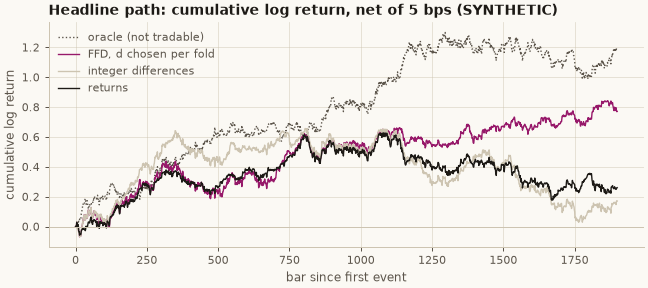

In [8]:
def draw(fig, c):
    ax = fig.subplots()
    curves = [
        (oracle_h["net"], "oracle (not tradable)", c["muted"], ":"),
        (nets_h[HEADLINE], "FFD, d chosen per fold", c["accent"], "-"),
        (nets_h["int_diff"], "integer differences", c["rule"], "-"),
        (nets_h[BASELINE], "returns", c["text"], "-"),
    ]
    for net, name, col, ls in curves:
        ax.plot(np.cumsum(net), color=col, linestyle=ls, linewidth=1.1, label=name)
    ax.axhline(0.0, color=c["rule"], linewidth=0.8)
    ax.set_title("Headline path: cumulative log return, net of 5 bps (SYNTHETIC)")
    ax.set_xlabel("bar since first event")
    ax.set_ylabel("cumulative log return")
    ax.legend(loc="upper left")


nbfigures.figure(
    "nb14-headline-equity",
    draw,
    alt="Cumulative net log return on the planted-signal path for the classifier on returns, on integer differences, on FFD features with d chosen per fold, and on the hidden mispricing (oracle).",
)

### Monte Carlo: 30 paths per signal strength (answers H1-H3 and the null control)

All 8 feature sets and the oracle on fresh paths (seeds `[209, strength index + 1, path]`), for
$s_m \in \{0, 0.004, 0.008\}$. $s_m = 0$ is the zero-signal control. These paths describe the
method and select nothing, so they are not trials. The second table is the paired comparisons
the hypotheses name: mean difference over the paths, its $t$-statistic and the share of paths
on which FFD is ahead.

In [9]:
MC_NAMES = TRIALS + ["oracle"]
WF_NAMES = [f"wf:{n}" for n in (BASELINE, "int_diff", "level", HEADLINE)]  # post hoc, see below


def one_path(k: int, rep: int) -> list[dict]:
    logp, m = simulate([SEED, k + 1, rep], STRENGTHS[k])
    ev = build(logp, m if STRENGTHS[k] > 0 else None)  # at s_m = 0 there is no oracle: m is 0
    names = [n for n in MC_NAMES if n in ev["feats"] or n == HEADLINE] + WF_NAMES
    res = run_series(ev, names)
    rows = []
    for name in names:
        rows.append(
            {
                "s_m": STRENGTHS[k],
                "rep": rep,
                "features": name,
                **summary(ev, res[name]),
                "d_mean": float(np.mean(res[name]["d"])) if res[name]["d"] else None,
            }
        )
    return rows


mc = pl.DataFrame(
    [row for k in range(len(STRENGTHS)) for rep in range(N_REPS) for row in one_path(k, rep)]
)
means = (
    mc.sort("s_m")
    .group_by("s_m", "features", maintain_order=True)
    .agg(pl.col("auc", "accuracy", "sharpe_net_ann", "sharpe_gross_ann", "turnover").mean())
    .pivot(on="s_m", index="features", values=["auc", "sharpe_net_ann"])
)
order = pl.DataFrame({"features": MC_NAMES, "i": range(len(MC_NAMES))})
with pl.Config(tbl_rows=20, float_precision=3, tbl_width_chars=200, tbl_cols=20):
    print("mean over paths, by s_m (k-fold):")
    print(means.join(order, on="features").sort("i").drop("i"))
dstar_mc = (
    mc.filter(pl.col("features") == HEADLINE)
    .group_by("s_m")
    .agg(pl.col("d_mean").mean())
    .sort("s_m")
)
print(
    "mean d chosen per fold by ffd_dstar, by s_m:",
    dict(zip(dstar_mc["s_m"], [round(v, 3) for v in dstar_mc["d_mean"]])),
)


def paired(a: str, b: str, metric: str) -> pl.DataFrame:
    rows = []
    for s_m in STRENGTHS:
        g = mc.filter(pl.col("s_m") == s_m)
        x = g.filter(pl.col("features") == a).sort("rep")[metric].to_numpy()
        y = g.filter(pl.col("features") == b).sort("rep")[metric].to_numpy()
        if len(x) == 0 or len(y) == 0:  # the oracle does not exist at s_m = 0
            continue
        d = x - y
        rows.append(
            {
                "test": f"{a} - {b}: {metric}",
                "s_m": s_m,
                "mean_diff": float(d.mean()),
                "t": float(d.mean() / (d.std(ddof=1) / math.sqrt(len(d)))),
                "share_ahead": float((d > 0).mean()),
            }
        )
    return pl.DataFrame(rows)


tests = pl.concat(
    [
        paired(HEADLINE, BASELINE, "auc").with_columns(pl.lit("H1").alias("h")),
        paired(HEADLINE, BASELINE, "sharpe_net_ann").with_columns(pl.lit("H2").alias("h")),
        paired(HEADLINE, "int_diff", "auc").with_columns(pl.lit("H3").alias("h")),
        paired(HEADLINE, "int_diff", "sharpe_net_ann").with_columns(pl.lit("-").alias("h")),
        paired("oracle", BASELINE, "auc").with_columns(pl.lit("-").alias("h")),
    ]
).select("h", "test", "s_m", "mean_diff", "t", "share_ahead")
with pl.Config(
    tbl_rows=30, float_precision=3, tbl_width_chars=200, tbl_cols=20, fmt_str_lengths=60
):
    print(tests)

mean over paths, by s_m (k-fold):
shape: (9, 7)
┌───────────┬─────────┬───────────┬───────────┬────────────────────┬──────────────────────┬──────────────────────┐
│ features  ┆ auc_0.0 ┆ auc_0.004 ┆ auc_0.008 ┆ sharpe_net_ann_0.0 ┆ sharpe_net_ann_0.004 ┆ sharpe_net_ann_0.008 │
│ ---       ┆ ---     ┆ ---       ┆ ---       ┆ ---                ┆ ---                  ┆ ---                  │
│ str       ┆ f64     ┆ f64       ┆ f64       ┆ f64                ┆ f64                  ┆ f64                  │
╞═══════════╪═════════╪═══════════╪═══════════╪════════════════════╪══════════════════════╪══════════════════════╡
│ returns   ┆ 0.478   ┆ 0.484     ┆ 0.490     ┆ -0.109             ┆ -0.149               ┆ -0.144               │
│ int_diff  ┆ 0.479   ┆ 0.498     ┆ 0.500     ┆ -0.073             ┆ 0.006                ┆ 0.021                │
│ level     ┆ 0.504   ┆ 0.512     ┆ 0.529     ┆ 0.217              ┆ 0.196                ┆ 0.324                │
│ ffd_d0.2  ┆ 0.500   ┆ 0.511   

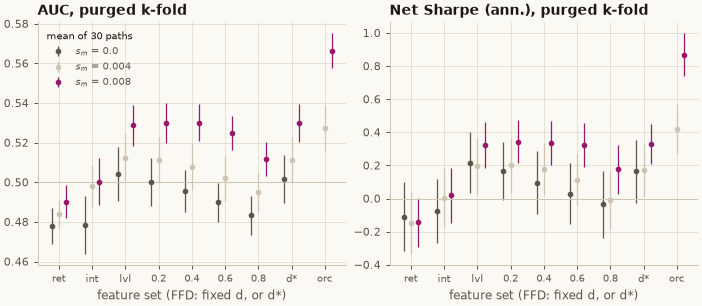

In [10]:
def draw(fig, c):
    left, right = fig.subplots(1, 2)
    names = [BASELINE, "int_diff", "level", *[f"ffd_d{d}" for d in D_FIXED], HEADLINE, "oracle"]
    labels = ["ret", "int", "lvl", *[f"{d}" for d in D_FIXED], "d*", "orc"]
    x = np.arange(len(names))
    for s_m, col, off in zip(STRENGTHS, [c["muted"], c["rule"], c["accent"]], (-0.22, 0.0, 0.22)):
        g = mc.filter(pl.col("s_m") == s_m)
        for ax, metric in ((left, "auc"), (right, "sharpe_net_ann")):
            vals = [g.filter(pl.col("features") == n)[metric].to_numpy() for n in names]
            mean = np.array([v.mean() if len(v) else np.nan for v in vals])
            se = np.array([v.std(ddof=1) / math.sqrt(len(v)) if len(v) else np.nan for v in vals])
            ax.errorbar(
                x + off,
                mean,
                yerr=1.96 * se,
                fmt="o",
                markersize=3.5,
                color=col,
                linewidth=1.0,
                label=f"$s_m$ = {s_m}",
            )
    left.axhline(0.5, color=c["rule"], linewidth=0.8)
    right.axhline(0.0, color=c["rule"], linewidth=0.8)
    for ax, title in ((left, "AUC, purged k-fold"), (right, "Net Sharpe (ann.), purged k-fold")):
        ax.set_xticks(x, labels, fontsize=8)
        ax.set_title(title)
        ax.set_xlabel("feature set (FFD: fixed d, or d*)")
    left.legend(loc="upper left", fontsize=8, title=f"mean of {N_REPS} paths", title_fontsize=8)


nbfigures.figure(
    "nb14-monte-carlo",
    draw,
    size=(7.8, 3.4),
    alt="Mean out-of-fold AUC and mean net Sharpe ratio over 30 simulated paths for each feature set (returns, integer differences, level, FFD at d 0.2 to 0.8, FFD with d chosen per fold, oracle) at three signal strengths, with 95 percent intervals.",
)

### Post hoc: walk-forward, to explain the null control

Added after the table above showed the zero-signal control failing (see Analysis). The same
Monte Carlo paths, with each fold's model fitted only on events **before** the test fold (the
first fold has no model and takes no bet), for returns, integer differences, the level and
`ffd_dstar`, whose $d$ is then also chosen on past data only. Not a trial: these paths select
nothing, and no walk-forward configuration was run on the headline path.

In [11]:
wf = mc.filter(pl.col("features").str.starts_with("wf:"))
wf_means = (
    wf.sort("s_m")
    .group_by("s_m", "features", maintain_order=True)
    .agg(pl.col("auc", "sharpe_net_ann").mean())
    .pivot(on="s_m", index="features", values=["auc", "sharpe_net_ann"])
)
with pl.Config(tbl_rows=20, float_precision=3, tbl_width_chars=200, tbl_cols=20):
    print("mean over paths, by s_m (walk-forward):")
    print(wf_means)
wf_tests = pl.concat(
    [
        paired(f"wf:{HEADLINE}", f"wf:{BASELINE}", "auc"),
        paired(f"wf:{HEADLINE}", f"wf:{BASELINE}", "sharpe_net_ann"),
        paired(f"wf:{HEADLINE}", "wf:int_diff", "auc"),
    ]
)
with pl.Config(
    tbl_rows=20, float_precision=3, tbl_width_chars=200, tbl_cols=20, fmt_str_lengths=60
):
    print(wf_tests)

mean over paths, by s_m (walk-forward):
shape: (4, 7)
┌──────────────┬─────────┬───────────┬───────────┬────────────────────┬──────────────────────┬──────────────────────┐
│ features     ┆ auc_0.0 ┆ auc_0.004 ┆ auc_0.008 ┆ sharpe_net_ann_0.0 ┆ sharpe_net_ann_0.004 ┆ sharpe_net_ann_0.008 │
│ ---          ┆ ---     ┆ ---       ┆ ---       ┆ ---                ┆ ---                  ┆ ---                  │
│ str          ┆ f64     ┆ f64       ┆ f64       ┆ f64                ┆ f64                  ┆ f64                  │
╞══════════════╪═════════╪═══════════╪═══════════╪════════════════════╪══════════════════════╪══════════════════════╡
│ wf:returns   ┆ 0.489   ┆ 0.493     ┆ 0.500     ┆ -0.083             ┆ -0.092               ┆ -0.172               │
│ wf:int_diff  ┆ 0.493   ┆ 0.502     ┆ 0.510     ┆ -0.073             ┆ 0.007                ┆ 0.079                │
│ wf:level     ┆ 0.510   ┆ 0.516     ┆ 0.530     ┆ -0.097             ┆ 0.010                ┆ 0.162                │
│ 

### Control: the `SYN_*` sample (no signal)

The same 8 trials on the five random-walk symbols, each cross-validated on its own, returns
averaged across symbols, recorded in a separate registry. No configuration should reach a
deflated Sharpe ratio of 0.95.

In [12]:
registry_control = evaluation.TrialRegistry(
    Path(_reg_env) if _reg_env else REGISTRY_DIR / "control.json"
)
ev_c = [build(control[s]) for s in SYMBOLS]
grid_c, nets_c, _ = run_grid(ev_c, f"control-{LABEL}", registry_control)
n_control = registry_control.n_trials
with pl.Config(tbl_rows=20, float_precision=3, tbl_width_chars=200, tbl_cols=20):
    print(grid_c.join(dsr_table(nets_c, registry_control), on="features", how="left"))
max_dsr_control = float(dsr_table(nets_c, registry_control)["dsr"].max())
print(f"control trials in the registry: {n_control}; highest DSR {max_dsr_control:.3f}")

shape: (8, 8)
┌───────────┬───────┬──────────┬────────────────┬──────────────────┬───────┬──────────┬───────┐
│ features  ┆ auc   ┆ accuracy ┆ sharpe_net_ann ┆ sharpe_gross_ann ┆ psr   ┆ turnover ┆ dsr   │
│ ---       ┆ ---   ┆ ---      ┆ ---            ┆ ---              ┆ ---   ┆ ---      ┆ ---   │
│ str       ┆ f64   ┆ f64      ┆ f64            ┆ f64              ┆ f64   ┆ f64      ┆ f64   │
╞═══════════╪═══════╪══════════╪════════════════╪══════════════════╪═══════╪══════════╪═══════╡
│ returns   ┆ 0.471 ┆ 0.496    ┆ 0.021          ┆ 0.305            ┆ 0.511 ┆ 0.150    ┆ 0.100 │
│ int_diff  ┆ 0.482 ┆ 0.501    ┆ -0.450         ┆ -0.280           ┆ 0.282 ┆ 0.106    ┆ 0.030 │
│ level     ┆ 0.546 ┆ 0.538    ┆ 1.850          ┆ 1.952            ┆ 0.992 ┆ 0.070    ┆ 0.863 │
│ ffd_d0.2  ┆ 0.539 ┆ 0.532    ┆ 1.436          ┆ 1.581            ┆ 0.969 ┆ 0.095    ┆ 0.708 │
│ ffd_d0.4  ┆ 0.515 ┆ 0.521    ┆ 1.071          ┆ 1.246            ┆ 0.917 ┆ 0.115    ┆ 0.529 │
│ ffd_d0.6  ┆ 0.495 ┆ 0.51

### Look-ahead and leakage checks

1. **Features are causal.** Replace every close after a cut with noise: every feature set,
   including the FFD series for every $d$ on the grid, is unchanged at and before the cut.
2. **Purge and embargo.** No training label overlaps a test label in any fold; unpurged k-fold
   has overlaps, so the purge is doing work.
3. **Test folds are unseen.** A fold's fitted model, including its standardisation and the $d$ it
   chooses, is bit-identical when the test fold's labels are replaced with noise.
4. **Shift test.** On a zero-signal path, the same features shifted **one bar into the future**
   (a deliberate leak of the next return) must lift the AUC far above 0.5, and the correctly
   lagged features must not. This shows the harness can see a one-bar look-ahead.

In [13]:
rng = np.random.default_rng([SEED, 10**6])
cut = N_BARS // 2
shocked = logp_h.copy()
shocked[cut + 1 :] = logp_h[cut] + np.cumsum(rng.normal(0.0, 0.05, N_BARS - cut - 1))
ev_s = build(shocked, m_h)
upto = ev_h["t"] <= cut
same_feats = {
    k: bool(np.array_equal(ev_h["feats"][k][upto], ev_s["feats"][k][upto])) for k in ev_h["feats"]
}
same_series = all(
    np.array_equal(ev_h["series"][d][: cut + 1], ev_s["series"][d][: cut + 1], equal_nan=True)
    for d in D_GRID
)
print(
    f"1. unchanged up to the cut: every feature set {all(same_feats.values())}, FFD for all d {same_series}"
)
assert all(same_feats.values()) and same_series

overlaps, naive = [], []
for (train, test), (ntrain, ntest) in zip(
    folds(ev_h), naive_kfold_splits(len(ev_h["t"]), N_SPLITS)
):
    overlaps.append(count_train_test_overlaps(ev_h["t"], ev_h["t"] + HORIZON, train, test))
    naive.append(count_train_test_overlaps(ev_h["t"], ev_h["t"] + HORIZON, ntrain, ntest))
print(f"2. train/test label overlaps per fold: purged {overlaps}, unpurged {naive}")
assert sum(overlaps) == 0 and sum(naive) > 0

identical = 0
for train, test in folds(ev_h):
    noisy = {**ev_h, "y": ev_h["y"].copy()}
    noisy["y"][test] = rng.integers(0, 2, len(test)).astype(float)
    d_a, d_b = choose_d(ev_h, train), choose_d(noisy, train)
    X = lagged(ev_h["series"][d_a], ev_h["t"])
    a, b = fit_fold(X, ev_h["y"], train), fit_fold(X, noisy["y"], train)
    identical += d_a == d_b and all(np.array_equal(u, v) for u, v in zip(a, b))
print(
    f"3. folds whose d and fitted model are bit-identical with a noisy test fold: {identical} of {N_SPLITS}"
)
assert identical == N_SPLITS

logp0, _ = simulate([SEED, 0, 0], 0.0)
ev0 = build(logp0)
shift = {}
for name in (BASELINE, "ffd_d0.4"):
    for lead in (0, 1):
        X = ev0["feats"][name]
        if lead:
            X = np.column_stack(
                [ev0["series"][1.0 if name == BASELINE else 0.4][ev0["t"] + 1], X[:, :-1]]
            )
        prob = np.full(len(ev0["t"]), np.nan)
        for train, test in folds(ev0):
            prob[test] = predict(fit_fold(X, ev0["y"], train), X[test])
        shift[(name, lead)] = auc(ev0["y"], prob)
print("4. zero-signal path, AUC:", {f"{n} lead={k}": round(v, 3) for (n, k), v in shift.items()})
assert all(abs(shift[(n, 0)] - 0.5) < 0.05 for n in (BASELINE, "ffd_d0.4"))
assert all(shift[(n, 1)] > 0.6 for n in (BASELINE, "ffd_d0.4"))

1. unchanged up to the cut: every feature set True, FFD for all d True
2. train/test label overlaps per fold: purged [0, 0, 0, 0, 0], unpurged [5, 10, 10, 10, 5]
3. folds whose d and fitted model are bit-identical with a noisy test fold: 5 of 5
4. zero-signal path, AUC: {'returns lead=0': 0.5, 'returns lead=1': 0.693, 'ffd_d0.4 lead=0': 0.506, 'ffd_d0.4 lead=1': 0.682}


## Analysis

In [14]:
h_row = {r["features"]: r for r in headline_table.iter_rows(named=True)}
print(
    f"headline path: AUC returns {h_row[BASELINE]['auc']:.3f}, int_diff {h_row['int_diff']['auc']:.3f}, "
    f"FFD {h_row[HEADLINE]['auc']:.3f} (oracle {oracle_row['auc']:.3f}); net Sharpe (ann.) "
    f"{h_row[BASELINE]['sharpe_net_ann']:.2f}, {h_row['int_diff']['sharpe_net_ann']:.2f}, "
    f"{h_row[HEADLINE]['sharpe_net_ann']:.2f} (oracle {oracle_row['sharpe_net_ann']:.2f})"
)
verdict = {}
for h in ("H1", "H2", "H3"):
    row = tests.filter((pl.col("h") == h) & (pl.col("s_m") == S_M)).row(0, named=True)
    null = tests.filter((pl.col("h") == h) & (pl.col("s_m") == 0.0)).row(0, named=True)
    verdict[h] = row["t"] > 1.645
    verdict[f"{h} null"] = abs(null["t"]) < 1.96
    print(
        f"{h} {row['test']}: s_m={S_M} mean diff {row['mean_diff']:+.4f}, t = {row['t']:.2f} -> "
        f"{'supported' if verdict[h] else 'rejected'}; null s_m=0: t = {null['t']:.2f} -> control "
        f"{'passes' if verdict[f'{h} null'] else 'fails'}"
    )
print(
    f"H4 (headline-path DSR >= 0.95): {'supported' if dsr_headline >= 0.95 else 'rejected'} (DSR {dsr_headline:.3f})"
)
print(
    f"control ({LABEL}): highest DSR of {n_control} trials {max_dsr_control:.3f} -> "
    f"{'FALSE DISCOVERY' if max_dsr_control >= 0.95 else 'passes (no false discovery)'}"
)
promote = (
    verdict["H1"]
    and verdict["H2"]
    and all(verdict[f"{h} null"] for h in ("H1", "H2", "H3"))
    and max_dsr_control < 0.95
)
print(
    "pre-registered decision rule:",
    "promote" if promote else "do not promote",
    "(over integer differences too)" if promote and verdict["H3"] else "",
)

headline path: AUC returns 0.505, int_diff 0.487, FFD 0.530 (oracle 0.572); net Sharpe (ann.) 0.22, 0.13, 0.60 (oracle 0.83)
H1 ffd_dstar - returns: auc: s_m=0.008 mean diff +0.0395, t = 7.44 -> supported; null s_m=0: t = 4.63 -> control fails
H2 ffd_dstar - returns: sharpe_net_ann: s_m=0.008 mean diff +0.4724, t = 6.06 -> supported; null s_m=0: t = 3.35 -> control fails
H3 ffd_dstar - int_diff: auc: s_m=0.008 mean diff +0.0295, t = 4.68 -> supported; null s_m=0: t = 2.90 -> control fails
H4 (headline-path DSR >= 0.95): rejected (DSR 0.779)
control (SYNTHETIC): highest DSR of 8 trials 0.863 -> passes (no false discovery)
pre-registered decision rule: do not promote 


The committed numbers come from SYNTHETIC data. They describe the procedure on data whose answer
is known, not a market.

1. **H1, H2 and H3 pass their own tests.** At $s_m = 0.008$, FFD's out-of-fold AUC is 0.040
   above returns' ($t$ = 7.4, ahead on 93% of paths), its net Sharpe ratio 0.47 higher
   (annualised, $t$ = 6.1), and its AUC 0.029 above the integer differences' ($t$ = 4.7). The
   oracle is 0.076 above returns, so FFD looks like it recovers about half of what is there.
2. **The null control fails, for all three.** With no signal at all ($s_m = 0$), FFD is already
   0.024 of AUC ($t$ = 4.6) and 0.27 of net Sharpe ratio ($t$ = 3.4) ahead of returns, and 0.023
   of AUC ahead of the integer differences ($t$ = 2.9). Most of the headline gap is there without
   a signal: over the null it is +0.016 of AUC and +0.20 of Sharpe ratio. Under the pre-registered
   rule that alone decides against promotion.
3. **Why the null fails (post hoc, walk-forward).** Two biases add up.
   - *Returns sit below chance.* In k-fold the returns classifier has AUC 0.478 and a net Sharpe
     ratio of -0.11 on random walks: a test fold with an unusual up-rate leaves a training set with
     the opposite one, the effect runbook 11 documented. Walk-forward shrinks it (0.489, -0.08).
   - *Memory features sit above chance in k-fold.* On random walks the `level` classifier earns
     +0.22 and `ffd_dstar` +0.17 of net Sharpe ratio. The model for a middle fold is fitted on bars
     before *and after* it, and a feature that carries the price level lets it use where the path
     went next. Purging does not stop this: it is not an overlap of labels. Walk-forward, where no
     model sees a later bar, removes it: -0.10 for both at $s_m = 0$, and the FFD-minus-returns
     Sharpe difference is -0.01 ($t$ = -0.1).

   Walk-forward, the planted signal is still there net of costs: FFD beats returns by 0.35 of
   Sharpe ratio at $s_m = 0.008$ ($t$ = 3.3), and by nothing at $s_m = 0.004$ ($t$ = 0.5). The AUC
   gap does *not* vanish under the walk-forward null (+0.017, $t$ = 3.4), so the pooled
   out-of-fold AUC is not a clean yardstick for memory features here. The follow-up (#217)
   traced this to the metric, not to a leak: AUC ranks events at different times against each
   other, and a later event's score, computed from past prices only, already reflects an
   earlier event's outcome. On random walks a fixed, causal level score reaches a within-fold
   AUC of about 0.54, almost all of it from pairs of events a few bars apart (see the
   `cross_validation` module page).
4. **FFD adds nothing over the level itself.** The ADF rule picks $d$ = 0.2 on four of the five
   headline folds (0.17 on average over the headline-strength paths), where the truncated weights
   pass 37% of the log price straight through. `ffd_dstar` and `level` then have the same k-fold
   AUC (0.530 and 0.529) and nearly the same walk-forward AUC (0.533, 0.530) and net Sharpe ratio
   (0.18, 0.16). The fixed-$d$ sets tell the same story: the AUC is flat from $d$ = 0 to 0.6
   (0.525-0.530) and falls toward returns as $d \to 1$ (0.512 at 0.8, 0.490 at 1). The signal
   planted here lives in the level, and the memory that finds it is the level.
5. **H4 is rejected.** On the headline path FFD's net Sharpe ratio is 0.60 annualised (PSR 0.951),
   and deflated by the 8 registered trials its DSR is 0.779: luck alone would reach 0.32 among
   eight configurations this dispersed. The best trial, `ffd_d0.6`, reaches 0.923.
6. **The `SYN_*` control passes as registered, narrowly.** Its highest DSR is 0.863, below 0.95.
   That trial is `level`, with a net Sharpe ratio of 1.85 annualised on seeded random walks, and
   `ffd_d0.2` has 1.44: the k-fold bias of point 3, on five 520-bar series.
7. **No look-ahead.** Features and FFD series ignore the future; purging leaves no label overlap;
   fitted models and chosen $d$ ignore the test fold; and the harness sees a one-bar leak (AUC
   0.69 and 0.68 with the leak, 0.50 and 0.51 without).

**Limits.** One generator, whose signal lives in the price level and so favours memory by
construction; one horizon (5 bars), one classifier, one FFD threshold (`1e-3`), a flat 5 bps
cost and 30 paths per strength. The walk-forward comparison and the AUC explanation are post hoc.
Nothing here was run on real prices.

## Promotion decision

**Decision: do not promote.** FFD features with $d$ chosen per training fold do not become the
default classifier input over returns (or over integer differences).

They pass H1-H3 on the planted signal, but the pre-registered null control fails: in purged
k-fold CV they beat returns by most of the same margin on random walks. The post hoc
walk-forward run shows why: purged k-fold flatters any feature that carries the price level and
handicaps returns. Where the signal is real, walk-forward still finds FFD ahead of returns net of
costs, but that comparison was not pre-registered, and FFD there did no better than the raw log
price.

What later runbooks should do instead:

- **Evaluate memory-bearing features walk-forward** (`cross_validation.walk_forward_splits`,
  added for #217), or with CPCV *and* a null run through the same splits
  (`cross_validation.null_score_distribution`). Purged k-fold removes label overlap, not a model's knowledge of where the price
  went after the test fold, and on the `SYN_*` random walks it gave the level a net Sharpe ratio
  of 1.85.
- **Judge on net returns against a null run**, not on pooled out-of-fold AUC, which stayed
  biased toward memory features even walk-forward.
- **Compare FFD with the level, not only with returns.** With $d$ chosen by the ADF rule, FFD
  was the level in all but name here.
- **Next runbook (candidate, pre-register it):** walk-forward FFD vs returns vs level, net Sharpe
  ratio, with the zero-signal null through the same splits, on real data.

The decision describes the **procedure** on synthetic series. It says nothing about FFD features
on any real instrument. Run the notebook on your own data (see the top cell) and read the control
tables next to your own.

## Self-review checklist

- [x] **No look-ahead in features.** Check 1 replaces every close after a cut with noise and no
  feature, and no FFD series for any $d$ on the grid, changes at or before the cut. Features at
  $t$ use closes up to $t$; the label and the position start at the close of $t$.
- [x] **Shift test.** Check 4: the same features moved one bar into the future lift the AUC on a
  zero-signal path from 0.50 to 0.69 (returns) and from 0.51 to 0.68 (FFD at 0.4), so a one-bar
  leak would be visible; the lagged features stay at chance.
- [x] **Purge and embargo honoured.** Check 2: zero train/test label overlaps in every fold
  (unpurged k-fold has 5-10). Check 3: each fold's chosen $d$ and fitted model are bit-identical
  when the test fold's labels are replaced with noise.
- [x] **k-fold is not a backtest, and here it is biased.** Stated in Method; the post hoc
  walk-forward run shows the size of the bias (Analysis, point 3).
- [x] **Trial count complete.** Headline path: the **8 pre-registered** feature sets, all in the
  `TrialRegistry`, and every DSR deflates by all 8. `SYN_*` control: the same 8 in their own
  registry. Fixed before the first run: horizon, lags, difference horizons, $d$ grid, folds,
  embargo, penalty, threshold, cost. Calibrated before the first run, on the oracle only: $\phi$
  and $s_m$, with every setting tried disclosed in Data. Not trials: the Monte Carlo paths
  (describe the method, select nothing) and the post hoc walk-forward rows, which were run on
  those paths only and are labelled post hoc.
- [x] **Null control for features with memory.** The zero-signal paths run through the same
  purged folds, and walk-forward (post hoc); that control is what exposed the k-fold bias (#217).
- [x] **Costs included.** 5 bps per unit of one-way turnover on every strategy, gross and net
  Sharpe ratios side by side.
- [x] **Seeds fixed.** The headline path is `[209, 0]`, Monte Carlo paths are
  `[209, strength index + 1, path]`, the shift-test path `[209, 0, 0]` and the check noise
  `[209, 10**6]`.
- [x] **Data labelled.** Tables, printouts and figure titles say SYNTHETIC; the planted path is
  hashed (stderr, platform-dependent bits) and the `fetch` sample's hash is in the footer.
- [ ] **Not covered here.** Real prices; other horizons, classifiers and FFD thresholds (a lower
  threshold would take more of the level out of FFD at small $d$, at the cost of a window longer
  than the 520-bar control); a pre-registered walk-forward comparison; triple-barrier labels
  (fixed-horizon labels keep the spans equal, so the CV has no uniqueness weights to get wrong).

## Reproducibility

In [15]:
import nbrepro

manifest = openquant.research.research_run_manifest(
    {
        "notebook": "14_fracdiff_features_classifier",
        "seed": SEED,
        "generator": {
            "n_bars": N_BARS,
            "sigma": SIGMA,
            "phi": PHI,
            "s_m": S_M,
            "strengths": list(STRENGTHS),
            "reps": N_REPS,
        },
        "pipeline": {
            "horizon": HORIZON,
            "warmup": WARMUP,
            "ffd_thresh": FFD_THRESH,
            "d_grid": D_GRID,
            "d_fixed": list(D_FIXED),
            "n_lags": N_LAGS,
            "diff_horizons": list(DIFF_HORIZONS),
            "n_splits": N_SPLITS,
            "pct_embargo": PCT_EMBARGO,
            "l2": L2,
            "cost_bps": COST_BPS,
            "ann": ANN,
        },
        "headline": HEADLINE,
        "symbols": SYMBOLS,
        "trials": {
            "planted": N_TRIALS_PLANTED,
            "control": n_control,
            "monte_carlo_paths": N_REPS * len(STRENGTHS),
        },
    }
)
openquant.data.record_dataset_hash(
    manifest,
    digest=meta["dataset_hash"],
    **{k: meta[k] for k in ("source", "symbols", "start", "end", "rows")},
)
manifest["planted_hash"] = planted_hash

nbrepro.footer(
    seed=SEED,
    data_hash=manifest["dataset_hash"],
    data=f"{LABEL} control",
    trials=manifest["config"]["trials"],
    config=manifest["config"],
    stderr={"planted": planted_hash},  # platform-dependent float bits, see Data
)

data hash:    sha256:b311c219efb2a19db449767cc8600139c030aad15496b011fc650b4880550eea
seed:         209
config:       e6ef2774e47c
data:         SYNTHETIC control
trials:       {'planted': 8, 'control': 8, 'monte_carlo_paths': 90}


planted:      sha256:4b86ce57f0dcb10a36a410a11e030dcea4f634aeaf66865ad592725a304b180d
git sha:      the commit containing this notebook (CI re-runs it there)
package:      pyopenquant built from that commit; dependencies from its uv.lock
